<ipython-input-2-ff4e9bb99b9c>:6: RuntimeWarning: overflow encountered in scalar multiply
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-2-ff4e9bb99b9c>:42: RuntimeWarning: invalid value encountered in scalar add
  y_values[i] = y_n + h * f(t_n, y_n)


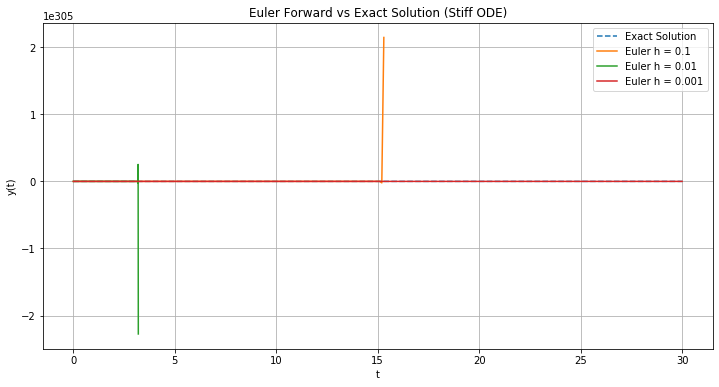

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ODE function
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Time settings
t_start = 0
t_end = 30

# Step sizes
h_values = [0.1, 0.01, 0.001]

plt.figure(figsize=(12, 6))

# ---------------------------------------
# Analytical solution (smooth reference)
# ---------------------------------------
t_fine = np.linspace(t_start, t_end, 5000)
plt.plot(t_fine, y_exact(t_fine), linestyle='--', label='Exact Solution')

# ---------------------------------------
# Euler Forward for each h
# ---------------------------------------
for h in h_values:
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))

    # Initial condition
    y_values[0] = 0

    # Euler Forward loop
    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]

        y_values[i] = y_n + h * f(t_n, y_n)

    plt.plot(t_values, y_values, label=f'Euler h = {h}')

# ---------------------------------------
# Plot formatting
# ---------------------------------------
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Euler Forward vs Exact Solution (Stiff ODE)")
plt.legend()
plt.grid(True)

plt.show()

For larger step sizes (h = 0.1 and 0.01), the solution becomes numerically unstable, producing overflow and invalid value warnings. This occurs because the stiff term −1000y requires a very small step size for stability. Euler Forward fails to handle this stiffness efficiently, confirming that explicit methods are not suitable for such problems.

h = 0.1 blew up at t ≈ 0.1000
h = 0.01 blew up at t ≈ 0.0200


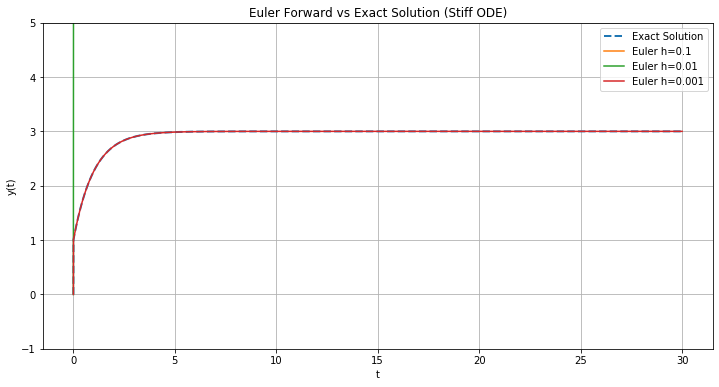

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ODE
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# Exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Settings
t_start = 0
t_end = 30
h_values = [0.1, 0.01, 0.001]

plt.figure(figsize=(12, 6))

# Exact solution
t_fine = np.linspace(t_start, t_end, 5000)
plt.plot(t_fine, y_exact(t_fine), linestyle='--', linewidth=2, label='Exact Solution')

# Threshold to stop explosion
BLOWUP_THRESHOLD = 50

for h in h_values:
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = 0

    valid_index = len(t_values)  # track where it blows up

    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]

        y_values[i] = y_n + h * f(t_n, y_n)

        # Stop if solution blows up
        if abs(y_values[i]) > BLOWUP_THRESHOLD or np.isnan(y_values[i]):
            valid_index = i
            print(f"h = {h} blew up at t ≈ {t_values[i]:.4f}")
            break

    # Plot only valid portion
    plt.plot(t_values[:valid_index], y_values[:valid_index], label=f'Euler h={h}')

# Formatting
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Euler Forward vs Exact Solution (Stiff ODE)")
plt.legend()
plt.grid(True)

# IMPORTANT: limit y-axis so explosion doesn't flatten everything
plt.ylim([-1, 5])

plt.show()

^^ for the above graph i looked up how to fix the graph 